In [ ]:
#  Model comparison, evaluation & explainability

# IMPORTS & DATA LOADING
#    - Load, split chronologically (reuse train.py logic)

# MODEL COMPARISON
#    - Logistic Regression / Random Forest / XGBoost
#    - Same pipeline, same split, same metrics
#    - Compare ROC-AUC, PR-AUC, training time

# EVALUATION PLOTS (best model)
#    - Precision-Recall curve
#    - ROC curve
#    - Confusion matrix at a chosen threshold

# GLOBAL EXPLAINABILITY
#    - SHAP summary plot (which features drive the model overall)

In [5]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, confusion_matrix,
)

import sys
from pathlib import Path

PROJECT_ROOT = Path(r"D:\My Projects\Fraud-Detection-End-to-End-ML-System")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FIGURES_DIR = PROJECT_ROOT / "notebooks" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Figures will be saved to: {FIGURES_DIR}")

from src import config
from src.data import load_data
from src.features import build_preprocessor
from src.train import time_based_split

print("Imports OK")

Figures will be saved to: D:\My Projects\Fraud-Detection-End-to-End-ML-System\notebooks\figures
Imports OK


In [6]:
# Load and split chronologically (same as training)
df = load_data()
train_df, valid_df = time_based_split(df, test_size=0.2)

X_train = train_df.drop(columns=[config.TARGET])
y_train = train_df[config.TARGET]
X_valid = valid_df.drop(columns=[config.TARGET])
y_valid = valid_df[config.TARGET]

# Class imbalance ratio for the models that support it
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Train: {X_train.shape[0]:,} | Valid: {X_valid.shape[0]:,}")
print(f"scale_pos_weight = {scale_pos_weight:.1f}")

Train: 472,432 | Valid: 118,108
scale_pos_weight = 27.5


In [7]:
# Section 1 — Model comparison
# Same preprocessing, same split, same metrics for all three models

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",   # handles imbalance for linear model
        random_state=config.RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        n_jobs=-1,
        random_state=config.RANDOM_STATE,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr",
        random_state=config.RANDOM_STATE,
        n_jobs=-1,
    ),
}

results = []

for name, model in models.items():
    print(f"Training {name}...")

    pipeline = Pipeline(steps=[
        ("preprocessor", build_preprocessor()),
        ("model", model),
    ])

    start = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start

    y_proba = pipeline.predict_proba(X_valid)[:, 1]

    results.append({
        "Model": name,
        "ROC-AUC": roc_auc_score(y_valid, y_proba),
        "PR-AUC": average_precision_score(y_valid, y_proba),
        "Train time (s)": round(train_time, 1),
    })

results_df = pd.DataFrame(results).sort_values("PR-AUC", ascending=False)
results_df


Training Logistic Regression...


D:\My Projects\Fraud-Detection-End-to-End-ML-System\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Random Forest...
Training XGBoost...


,Model,ROC-AUC,PR-AUC,Train time (s)
2,XGBoost,0.815961,0.313216,7.9
0,Logistic Regression,0.753024,0.144969,53.1
1,Random Forest,0.772503,0.138532,11.5


In [8]:
# Section 2 — Evaluation of the best model (XGBoost)

best_pipeline = Pipeline(steps=[
    ("preprocessor", build_preprocessor()),
    ("model", XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr",
        random_state=config.RANDOM_STATE, n_jobs=-1,
    )),
])

best_pipeline.fit(X_train, y_train)
y_proba = best_pipeline.predict_proba(X_valid)[:, 1]

roc_auc = roc_auc_score(y_valid, y_proba)
pr_auc = average_precision_score(y_valid, y_proba)
print(f"ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}")

ROC-AUC: 0.8160 | PR-AUC: 0.3132


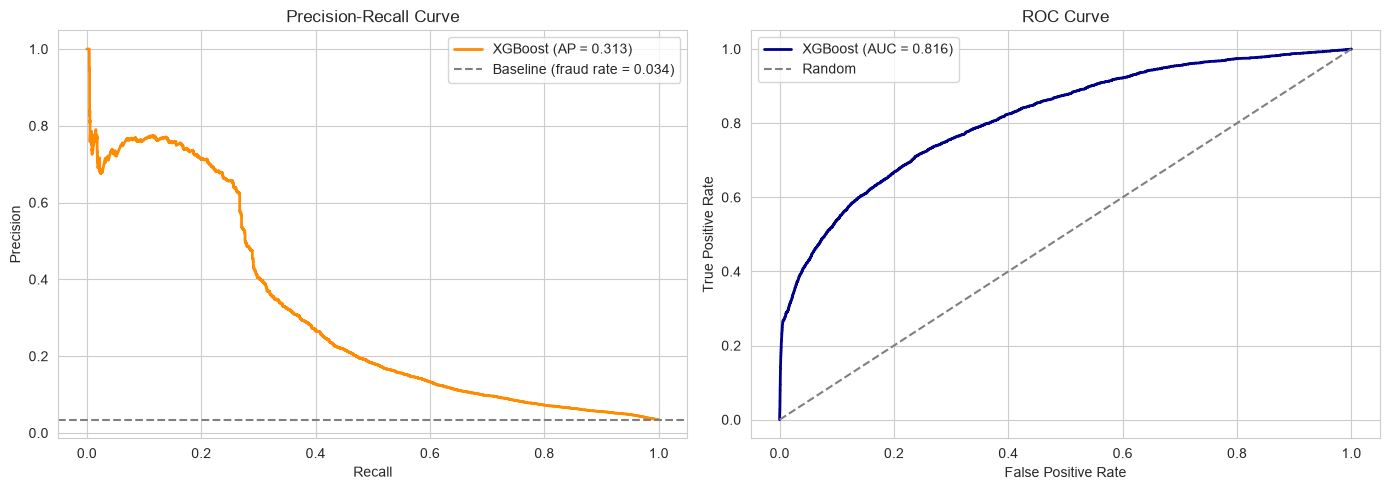

In [9]:
# Precision-Recall and ROC curves side by side
precision, recall, _ = precision_recall_curve(y_valid, y_proba)
fpr, tpr, _ = roc_curve(y_valid, y_proba)
baseline = y_valid.mean()  # fraud rate = PR baseline

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall
axes[0].plot(recall, precision, color="darkorange", lw=2,
             label=f"XGBoost (AP = {pr_auc:.3f})")
axes[0].axhline(baseline, color="grey", ls="--",
                label=f"Baseline (fraud rate = {baseline:.3f})")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve")
axes[0].legend()

# ROC
axes[1].plot(fpr, tpr, color="darkblue", lw=2,
             label=f"XGBoost (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], color="grey", ls="--", label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "pr_roc_curves.png", dpi=120, bbox_inches="tight")
plt.show()

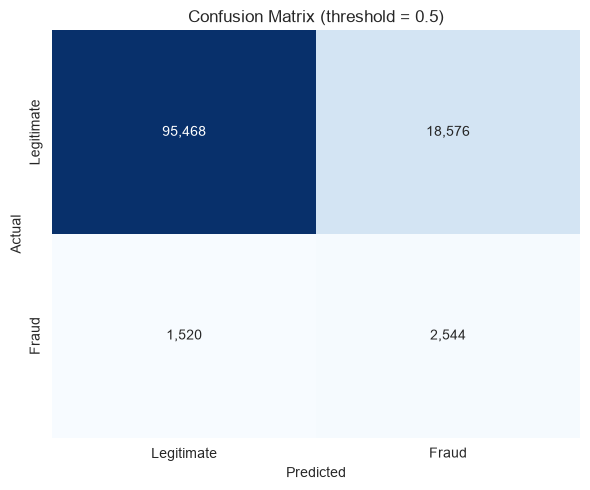

True frauds caught:   2,544 (62.6% of all fraud)
Frauds missed:        1,520
False alarms:         18,576
Legitimate approved:  95,468


In [10]:
# Confusion matrix at a business-relevant threshold
threshold = 0.5  # start with default, we'll discuss tuning
y_pred = (y_proba >= threshold).astype(int)

cm = confusion_matrix(y_valid, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["Legitimate", "Fraud"],
            yticklabels=["Legitimate", "Fraud"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix (threshold = {threshold})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

# Print the business interpretation
tn, fp, fn, tp = cm.ravel()
print(f"True frauds caught:   {tp:,} ({tp/(tp+fn)*100:.1f}% of all fraud)")
print(f"Frauds missed:        {fn:,}")
print(f"False alarms:         {fp:,}")
print(f"Legitimate approved:  {tn:,}")

## Threshold selection: the precision–recall trade-off

The confusion matrix above uses the default 0.5 threshold, but that value is
almost never optimal for imbalanced fraud detection. The model outputs a
*probability*; the threshold decides where to draw the line between "approve"
and "flag".

Lowering the threshold catches more fraud (higher recall) at the cost of more
false alarms (lower precision). Raising it does the opposite. The right choice
is a **business decision**, driven by the relative cost of the two errors:

- A **missed fraud** (false negative) costs the transaction amount.
- A **false alarm** (false positive) costs an investigation and customer friction.

In insurance and banking, a missed high-value fraud typically costs far more
than a manual review, so the threshold is usually set **below 0.5** to favour
recall. The curve below quantifies this trade-off across all thresholds.

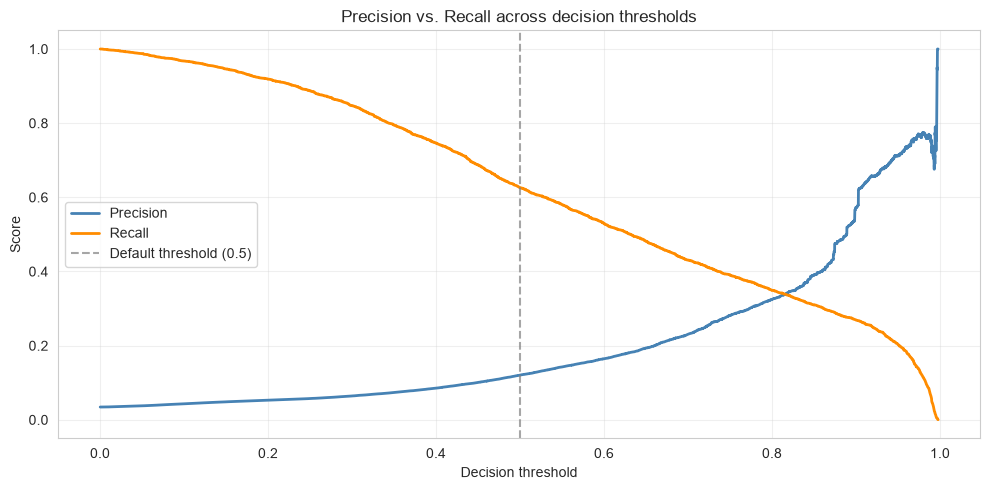

In [14]:
# Precision and recall as a function of the decision threshold
precision, recall, thresholds = precision_recall_curve(y_valid, y_proba)

# precision_recall_curve returns one more precision/recall than thresholds,
# so we drop the last point to align the arrays
precision = precision[:-1]
recall = recall[:-1]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precision, label="Precision", color="steelblue", lw=2)
plt.plot(thresholds, recall, label="Recall", color="darkorange", lw=2)
plt.axvline(0.5, color="grey", ls="--", alpha=0.7, label="Default threshold (0.5)")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Precision vs. Recall across decision thresholds")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "threshold_tradeoff.png", dpi=120, bbox_inches="tight")
plt.show()

In [12]:
# Quantify the trade-off at a few candidate thresholds
print(f"{'Threshold':>10} | {'Recall':>7} | {'Precision':>9} | {'Frauds caught':>13} | {'False alarms':>12}")
print("-" * 65)

total_fraud = y_valid.sum()
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_valid, y_pred_t).ravel()
    rec = tp / (tp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"{t:>10.1f} | {rec:>6.1%} | {prec:>8.1%} | {tp:>13,} | {fp:>12,}")

 Threshold |  Recall | Precision | Frauds caught | False alarms
-----------------------------------------------------------------
       0.3 |  84.7% |     6.4% |         3,442 |       50,119
       0.4 |  74.7% |     8.5% |         3,034 |       32,456
       0.5 |  62.6% |    12.0% |         2,544 |       18,576
       0.6 |  53.0% |    16.5% |         2,153 |       10,916
       0.7 |  43.1% |    23.1% |         1,750 |        5,842


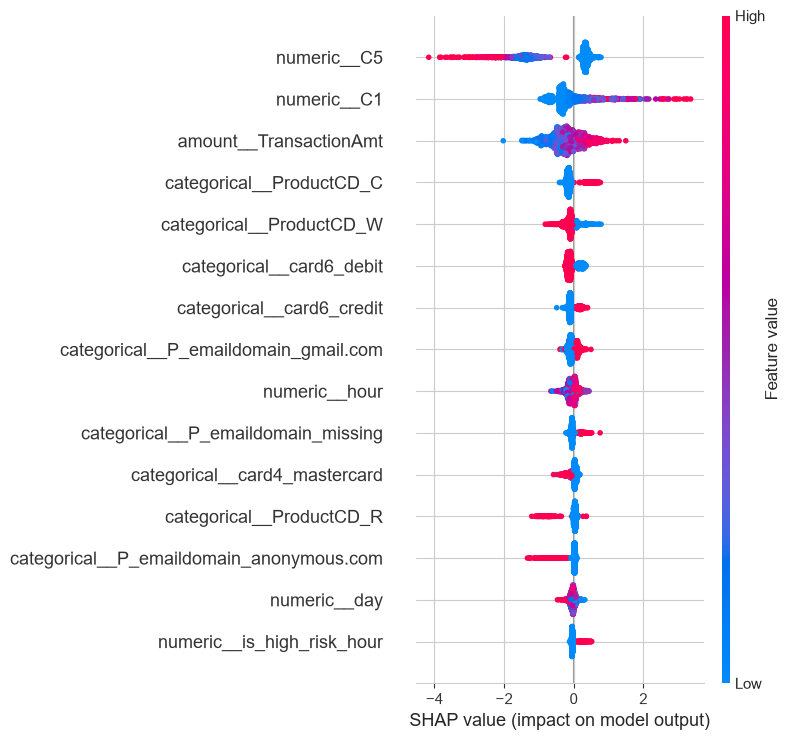

In [13]:
import shap

# Reuse the trained best_pipeline from Section 2
preprocessor = best_pipeline.named_steps["preprocessor"]
model = best_pipeline.named_steps["model"]

# Transform a sample of the validation set (SHAP on all 118k rows is slow)
X_sample = X_valid.sample(n=2000, random_state=config.RANDOM_STATE)
X_transformed = preprocessor.transform(X_sample)

# Feature names from the ColumnTransformer
feature_names = (
    preprocessor.named_steps["column_transformer"].get_feature_names_out()
)

# Compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_transformed)

# Summary plot (global feature importance + direction)
plt.figure()
shap.summary_plot(
    shap_values, X_transformed,
    feature_names=feature_names,
    max_display=15, show=False,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()